In [ ]:
!pip install kaggle

In [ ]:
import os

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_620804d050d171ea951ab3f2e27791d4'

In [ ]:
!mkdir -p ~/.kaggle
!echo $KAGGLE_API_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:04<00:00, 37.7MB/s]



In [ ]:
!unzip brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [ ]:
import os
os.listdir()

['.config',
 'Training',
 'Testing',
 'brain-tumor-mri-dataset.zip',
 'sample_data']

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_gen.flow_from_directory(
    "Training",
    target_size=(224,224),
    class_mode="categorical"
)

test_data = test_gen.flow_from_directory(
    "Testing",
    target_size=(224,224),
    class_mode="categorical",
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


base_model.trainable = False


model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(4, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.7821 - loss: 0.6011 - val_accuracy: 0.7769 - val_loss: 0.5768
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.8568 - loss: 0.3844 - val_accuracy: 0.8119 - val_loss: 0.5631
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.8805 - loss: 0.3157 - val_accuracy: 0.8288 - val_loss: 0.5127
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.8918 - loss: 0.2881 - val_accuracy: 0.8569 - val_loss: 0.4599
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.8948 - loss: 0.2846 - val_accuracy: 0.8444 - val_loss: 0.4784
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.9021 - loss: 0.2510 - val_accuracy: 0.8637 - val_loss: 0.4868
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.9091 - loss: 0.2328 - val_accuracy: 0.8537 - val_loss: 0.4914
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.9146 - loss: 0.2293 - val_accu

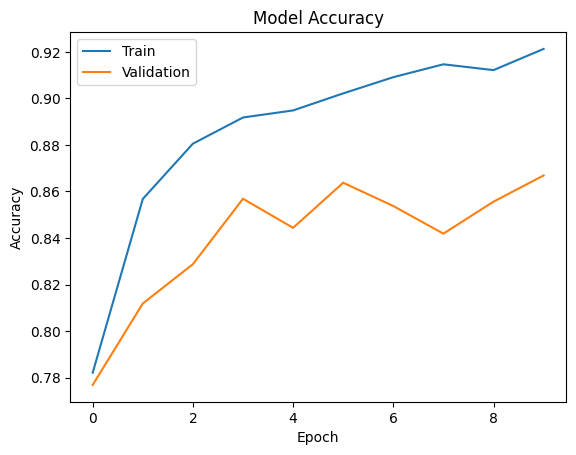

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

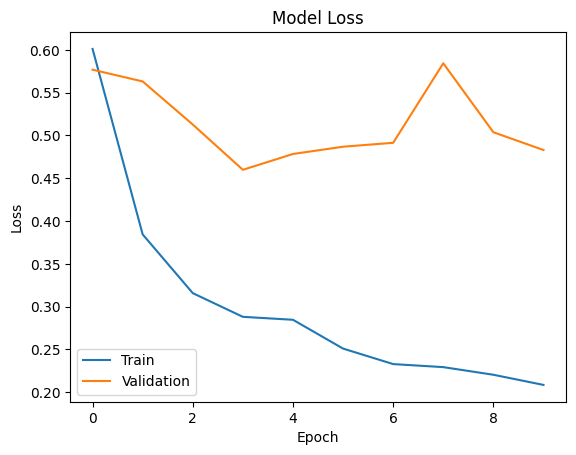

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [14]:
model.save("brain_tumor_model.h5")

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np


pred = model.predict(test_data)

pred_classes = np.argmax(pred, axis=1)
true_classes = test_data.classes


cm = confusion_matrix(true_classes, pred_classes)

print(cm)

50/50 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step
[[277  70  34  19]
 [ 13 318  23  46]
 [  3   2 394   1]
 [  1   1   0 398]]


              precision    recall  f1-score   support

      glioma       0.94      0.69      0.80       400
  meningioma       0.81      0.80      0.80       400
     notumor       0.87      0.98      0.93       400
   pituitary       0.86      0.99      0.92       400

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.86      1600
weighted avg       0.87      0.87      0.86      1600



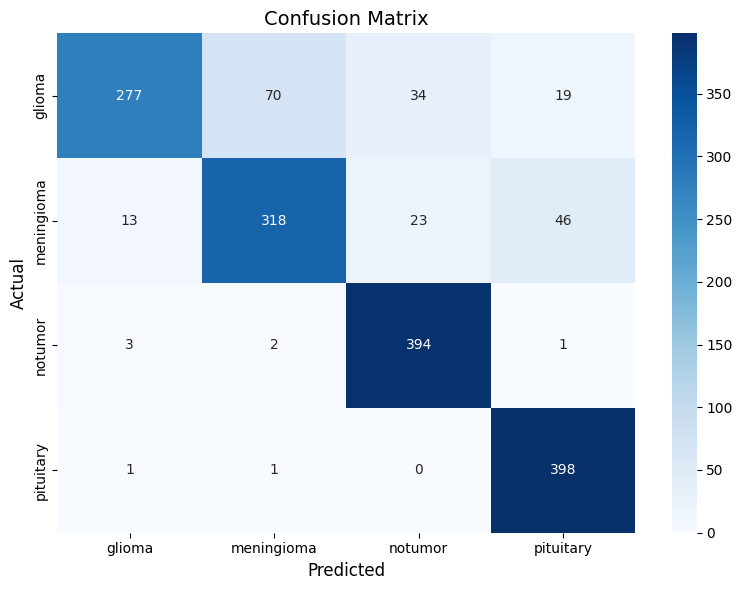

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']


print(classification_report(true_classes, pred_classes, target_names=class_names))


cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
import os

os.listdir("Testing")

['notumor', 'glioma', 'meningioma', 'pituitary']

In [17]:
os.listdir("Testing/glioma")[:5]

['Te-gl_86.jpg',
 'Te-gl_264.jpg',
 'Te-gl_53.jpg',
 'Te-gl_2.jpg',
 'Te-gl_380.jpg']

In [18]:
img_path = "/content/Testing/notumor/Te-no_102.jpg"

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: notumor


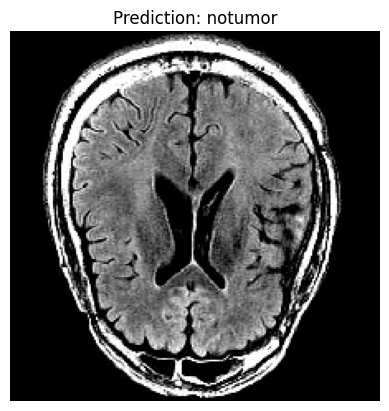

In [19]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

prediction = model.predict(img_array)

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

predicted_class = class_names[np.argmax(prediction)]

plt.imshow(img)
plt.title(f"Prediction: {predicted_class}")
plt.axis('off')

print("Prediction:", predicted_class)

In [20]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image



In [21]:
def build_grad_cam_model(base_model, full_model):

    last_conv_layer = base_model.get_layer("Conv_1")


    conv_output = last_conv_layer.output


    conv_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=conv_output
    )

    classifier_input = tf.keras.Input(shape=conv_output.shape[1:])
    x = classifier_input


    for layer in full_model.layers[1:]:
        x = layer(x)

    classifier_model = tf.keras.Model(
        inputs=classifier_input,
        outputs=x
    )

    return conv_model, classifier_model




In [22]:

def make_gradcam_heatmap(img_array, conv_model, classifier_model, class_idx=None):

    with tf.GradientTape() as tape:

        conv_outputs = conv_model(img_array)
        tape.watch(conv_outputs)


        predictions = classifier_model(conv_outputs)

        if class_idx is None:
            class_idx = tf.argmax(predictions[0])

        loss = predictions[:, class_idx]


    grads = tape.gradient(loss, conv_outputs)


    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))


    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)


    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()




In [23]:

def display_gradcam(img_path, heatmap, alpha=0.4):


    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)


    superimposed = cv2.addWeighted(img_rgb, 1 - alpha, heatmap_colored, alpha, 0)


    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_rgb);        axes[0].set_title("Original Image");  axes[0].axis('off')
    axes[1].imshow(heatmap, cmap='jet'); axes[1].set_title("Grad-CAM Heatmap"); axes[1].axis('off')
    axes[2].imshow(superimposed);   axes[2].set_title("Overlay");         axes[2].axis('off')
    plt.tight_layout()
    plt.show()




In [24]:

img_path = "/content/Testing/notumor/Te-no_102.jpg"
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']



In [25]:

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0
img_array = img_array.astype(np.float32)



In [26]:

conv_model, classifier_model = build_grad_cam_model(base_model, model)



In [27]:

conv_out = conv_model(img_array)
pred = classifier_model(conv_out)
predicted_class = class_names[np.argmax(pred[0])]
print(f"Predicted: {predicted_class} | Confidence: {np.max(pred[0]):.2%}")



Predicted: glioma | Confidence: 41.75%


In [28]:

heatmap = make_gradcam_heatmap(img_array, conv_model, classifier_model)



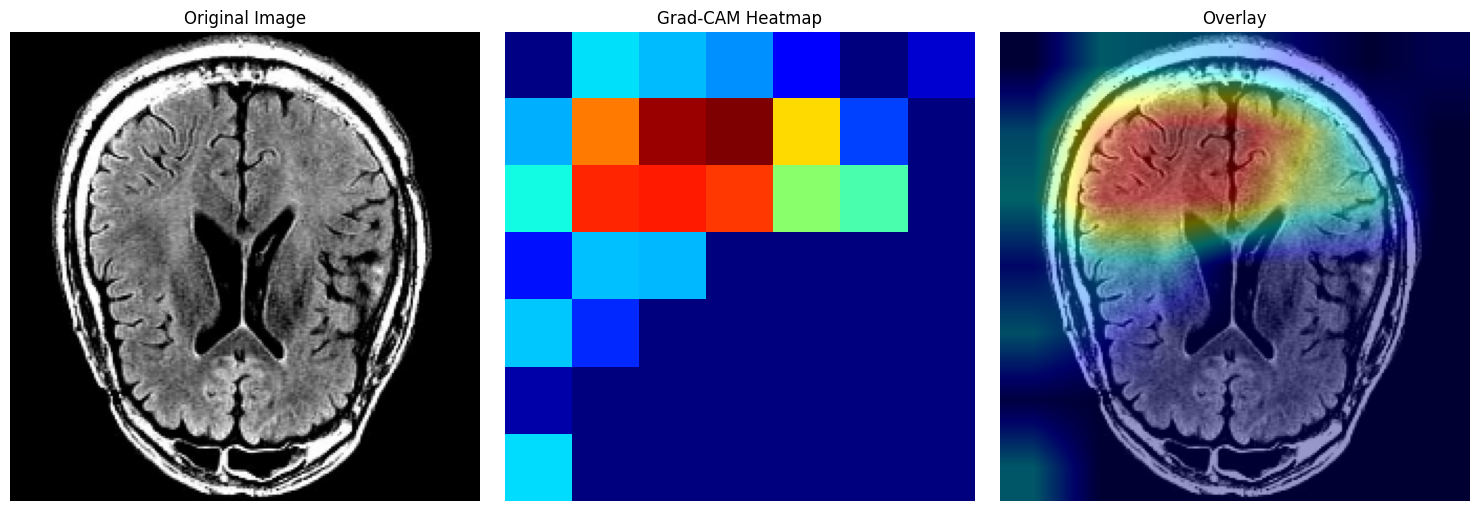

In [29]:

display_gradcam(img_path, heatmap)

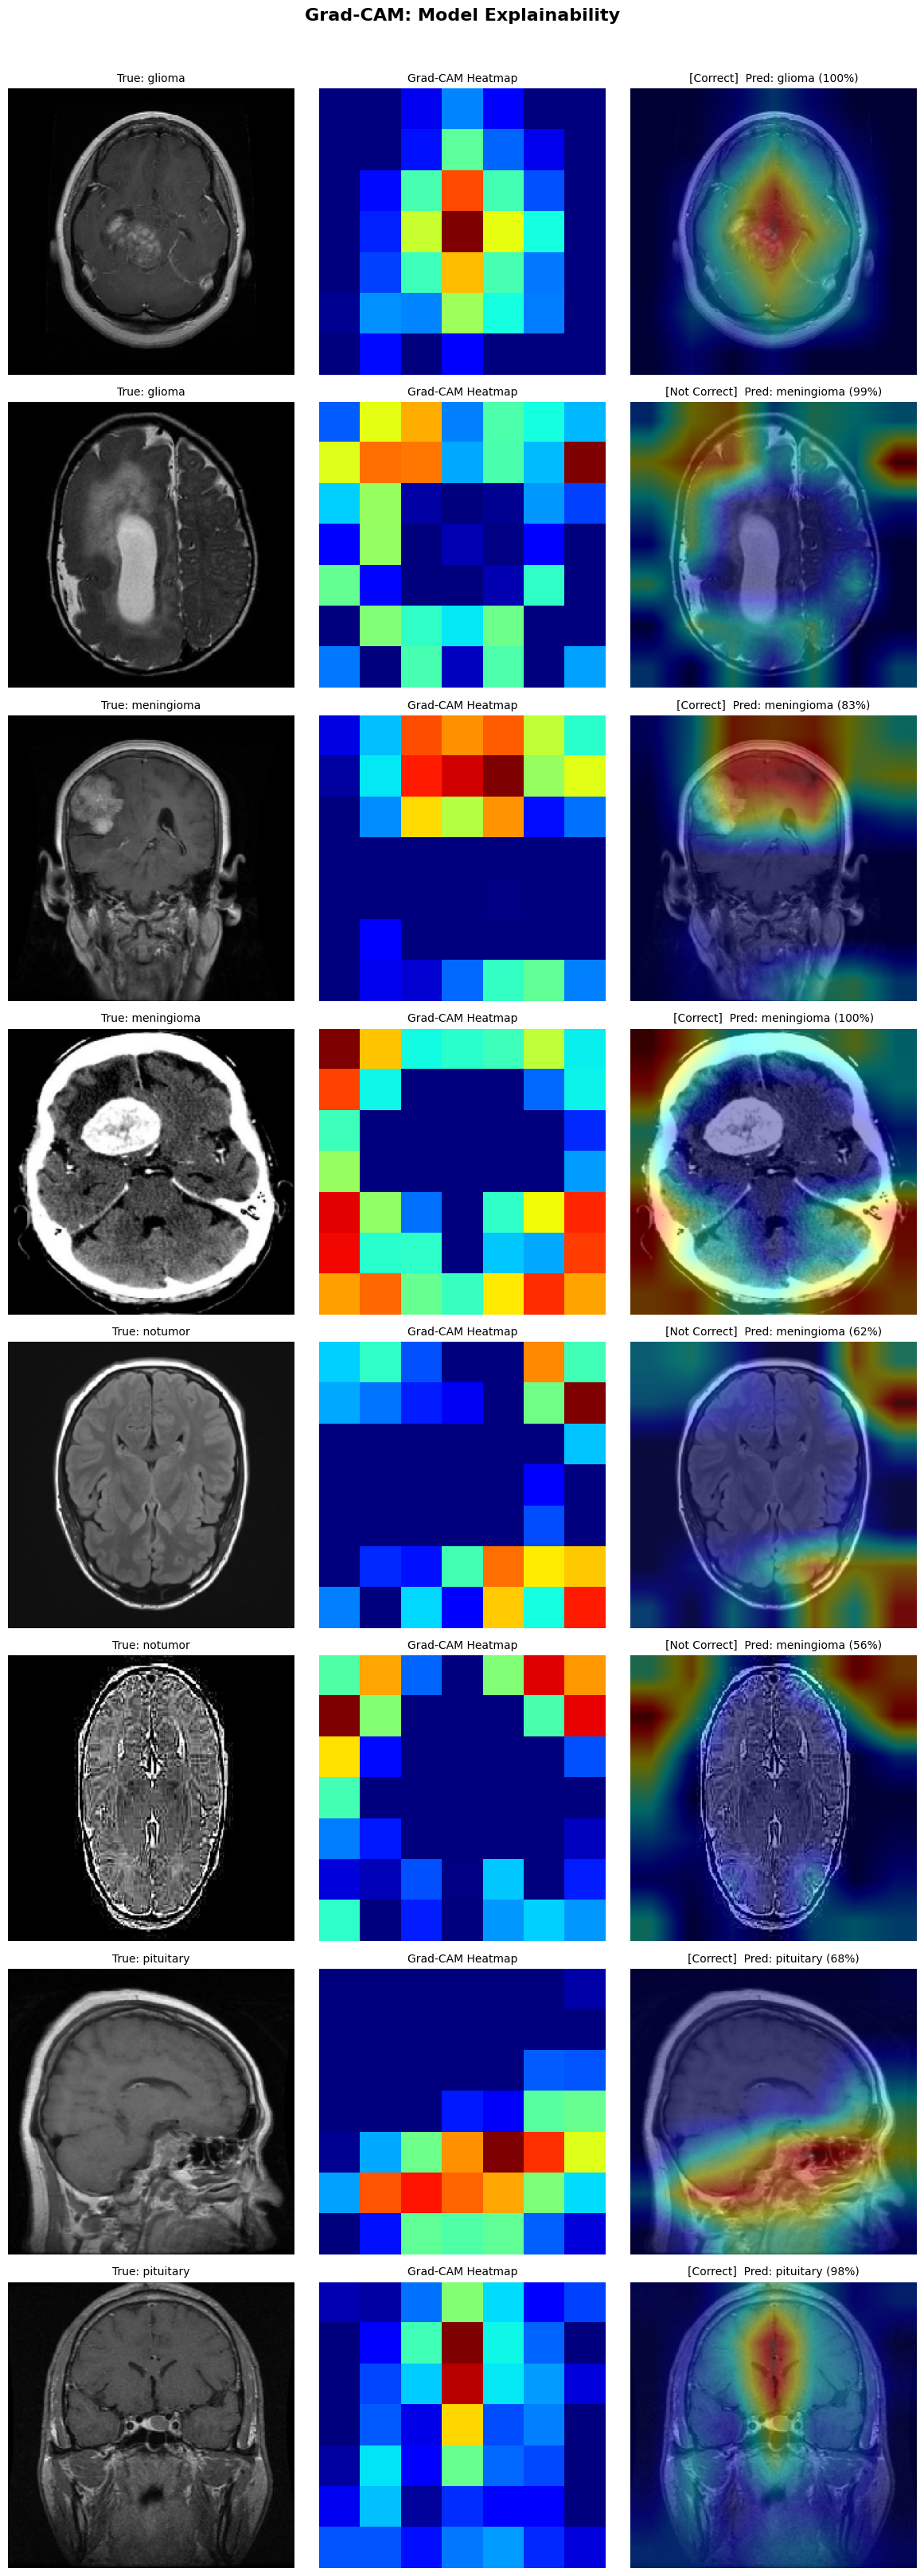

In [33]:
import os
import random

def get_sample_images(test_dir, class_names, n=2):
    samples = []
    for cls in class_names:
        folder = os.path.join(test_dir, cls)
        images = os.listdir(folder)
        chosen = random.sample(images, n)
        for img_name in chosen:
            samples.append((os.path.join(folder, img_name), cls))
    return samples


def gradcam_grid(test_dir, class_names, conv_model, classifier_model, n=2):
    samples = get_sample_images(test_dir, class_names, n)

    fig, axes = plt.subplots(
        len(class_names) * n, 3,
        figsize=(12, 4 * len(class_names) * n)
    )

    for i, (img_path, true_label) in enumerate(samples):

        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array_expanded = np.expand_dims(img_array, axis=0) / 255.0
        img_array_expanded = img_array_expanded.astype(np.float32)


        conv_out = conv_model(img_array_expanded)
        pred = classifier_model(conv_out)
        predicted_label = class_names[np.argmax(pred[0])]
        confidence = np.max(pred[0])

        heatmap = make_gradcam_heatmap(img_array_expanded, conv_model, classifier_model)


        img_cv = cv2.resize(np.uint8(img_array), (224, 224))
        img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
        heatmap_resized = cv2.resize(heatmap, (224, 224))
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
        superimposed = cv2.addWeighted(img_rgb, 0.6, heatmap_colored, 0.4, 0)


        correct = "[Correct] " if true_label == predicted_label else "[Not Correct] "

        axes[i][0].imshow(img_rgb)
        axes[i][0].set_title(f"True: {true_label}", fontsize=10)
        axes[i][0].axis('off')

        axes[i][1].imshow(heatmap, cmap='jet')
        axes[i][1].set_title("Grad-CAM Heatmap", fontsize=10)
        axes[i][1].axis('off')

        axes[i][2].imshow(superimposed)
        axes[i][2].set_title(f"{correct} Pred: {predicted_label} ({confidence:.0%})", fontsize=10)
        axes[i][2].axis('off')

    plt.suptitle('Grad-CAM: Model Explainability', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


gradcam_grid("Testing", class_names, conv_model, classifier_model, n=2)